In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

trained_model = load_model("../models/resnet50_best.keras")

print("Loaded:", type(trained_model))

Loaded: <class 'keras.src.models.sequential.Sequential'>


In [2]:
base_model = trained_model.layers[0]

gap = trained_model.layers[1]
drop1 = trained_model.layers[2]
dense1 = trained_model.layers[3]
drop2 = trained_model.layers[4]
dense2 = trained_model.layers[5]

print(base_model.name)
print(dense2.units)

resnet50
5


In [3]:
from tensorflow.keras.models import Model

x = base_model.output
x = gap(x)
x = drop1(x, training=False)
x = dense1(x)
x = drop2(x, training=False)
outputs = dense2(x)

functional_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("✅ Functional model created")

✅ Functional model created


In [5]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = "../dataset/basophil/BA_100102.jpg"

img = image.load_img(
    IMG_PATH,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

print("Image shape:", img_array.shape)

Image shape: (1, 224, 224, 3)


In [7]:
pred_old = trained_model.predict(img_array, verbose=0)
pred_new = functional_model.predict(img_array, verbose=0)

print("Sequential :", np.argmax(pred_old), np.max(pred_old))
print("Functional :", np.argmax(pred_new), np.max(pred_new))

print("Difference:", np.max(np.abs(pred_old - pred_new)))

Sequential : 3 0.987357
Functional : 3 0.987357
Difference: 0.0


In [9]:
last_conv_layer = functional_model.get_layer("conv5_block3_out")

print("Grad-CAM layer:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

Grad-CAM layer: conv5_block3_out
Output shape: (None, 7, 7, 2048)


In [10]:
grad_model = tf.keras.models.Model(
    inputs=functional_model.inputs,
    outputs=[
        last_conv_layer.output,
        functional_model.output
    ]
)

print("✅ Grad-CAM model created")

✅ Grad-CAM model created


In [11]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array, training=False)

    predicted_class = tf.argmax(predictions[0])

    class_output = predictions[:, predicted_class]

grads = tape.gradient(
    class_output,
    conv_outputs
)

print("Conv output shape:", conv_outputs.shape)
print("Gradient shape:", grads.shape)
print("Predicted class:", predicted_class.numpy())


C:\Users\kaush\SynthMicro\venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Conv output shape: (1, 7, 7, 2048)
Gradient shape: (1, 7, 7, 2048)
Predicted class: 3


In [12]:
# Remove the batch dimension
conv_outputs = conv_outputs[0]
grads = grads[0]

# Global average pooling of gradients
weights = tf.reduce_mean(grads, axis=(0, 1))

# Weighted combination of feature maps
cam = tf.reduce_sum(
    tf.multiply(conv_outputs, weights),
    axis=-1
)

# Apply ReLU
cam = tf.maximum(cam, 0)

# Normalize between 0 and 1
cam = cam / (tf.reduce_max(cam) + 1e-8)

heatmap = cam.numpy()

print("Heatmap shape:", heatmap.shape)
print("Minimum:", heatmap.min())
print("Maximum:", heatmap.max())

Heatmap shape: (7, 7)
Minimum: 0.0
Maximum: 0.99999815


In [17]:
import os

DATASET_PATH = "../dataset"

class_names = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Classes:", class_names)

Classes: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


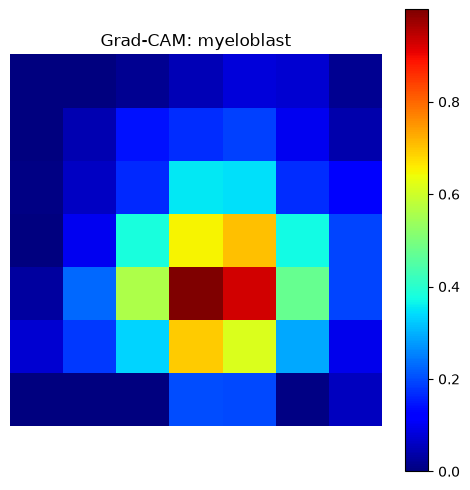

In [18]:
plt.figure(figsize=(6, 6))

plt.imshow(heatmap, cmap="jet")
plt.colorbar()

plt.title(
    f"Grad-CAM: {class_names[predicted_class.numpy()]}"
)

plt.axis("off")
plt.show()

In [19]:
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (224, 224)
).numpy().squeeze()

print("Resized heatmap:", heatmap_resized.shape)

Resized heatmap: (224, 224)


In [20]:
original_image = np.array(img)

print("Original image shape:", original_image.shape)

Original image shape: (224, 224, 3)


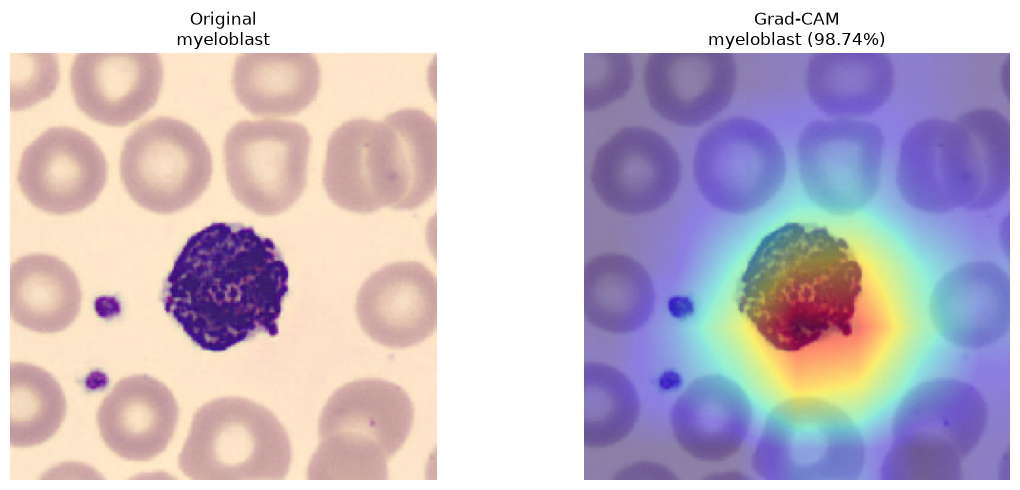

In [21]:
plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)

plt.imshow(original_image)
plt.title(
    f"Original\n{class_names[predicted_class.numpy()]}"
)
plt.axis("off")


# Grad-CAM overlay
plt.subplot(1, 2, 2)

plt.imshow(original_image)
plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)

plt.title(
    f"Grad-CAM\n"
    f"{class_names[predicted_class.numpy()]} "
    f"({float(predictions[0, predicted_class])*100:.2f}%)"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
predicted_index = predicted_class.numpy()
confidence = float(predictions[0, predicted_index])

print("=" * 55)
print("SYNTHMICRO — PHASE 6 XAI RESULT")
print("=" * 55)

print(f"Predicted Class : {class_names[predicted_index]}")
print(f"Confidence      : {confidence * 100:.2f}%")
print(f"Grad-CAM Layer  : {last_conv_layer.name}")
print(f"Feature Map     : {tuple(conv_outputs.shape)}")

print("=" * 55)
print("Interpretation:")
print(
    f"The Grad-CAM visualization shows the image regions "
    f"that contributed most strongly to the model's "
    f"prediction of {class_names[predicted_index]}."
)

SYNTHMICRO — PHASE 6 XAI RESULT
Predicted Class : myeloblast
Confidence      : 98.74%
Grad-CAM Layer  : conv5_block3_out
Feature Map     : (7, 7, 2048)
Interpretation:
The Grad-CAM visualization shows the image regions that contributed most strongly to the model's prediction of myeloblast.


In [23]:
# Top-3 predictions
prediction = predictions[0].numpy()

top_indices = np.argsort(prediction)[::-1][:3]

print("=" * 45)
print("TOP-3 PREDICTIONS")
print("=" * 45)

for rank, idx in enumerate(top_indices, start=1):
    print(
        f"{rank}. {class_names[idx]:20s} "
        f"{prediction[idx] * 100:.2f}%"
    )

TOP-3 PREDICTIONS
1. myeloblast           98.74%
2. erythroblast         1.26%
3. monocyte             0.00%


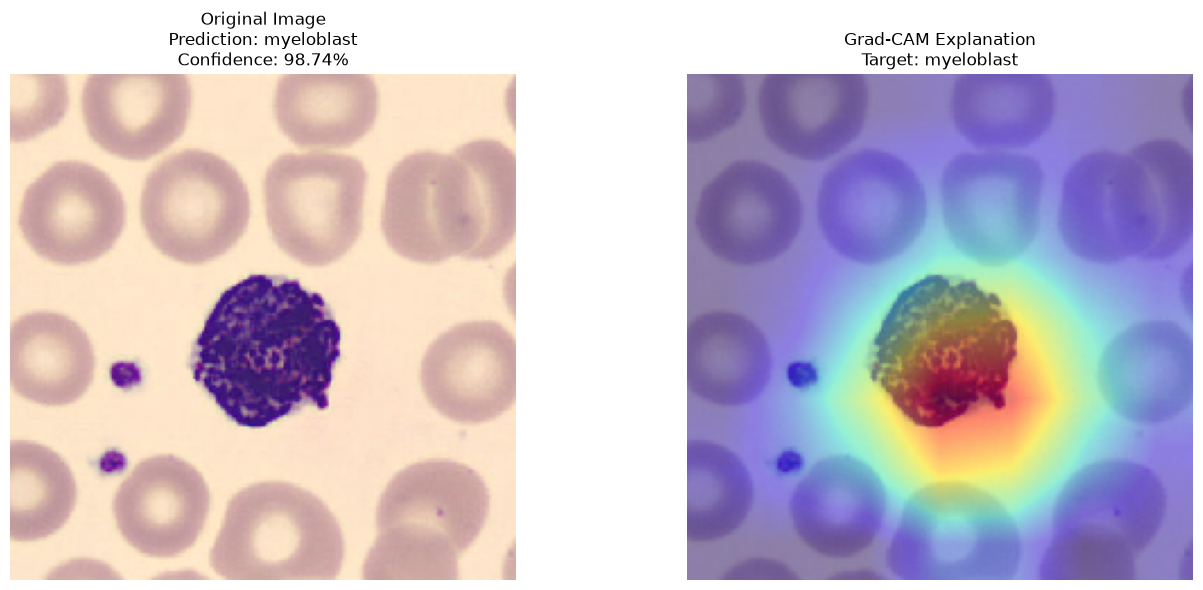

In [24]:
fig = plt.figure(figsize=(14, 6))

# Original image
ax1 = plt.subplot(1, 2, 1)

ax1.imshow(original_image)
ax1.set_title(
    f"Original Image\n"
    f"Prediction: {class_names[predicted_class.numpy()]}\n"
    f"Confidence: {float(predictions[0, predicted_class]) * 100:.2f}%"
)
ax1.axis("off")


# Grad-CAM
ax2 = plt.subplot(1, 2, 2)

ax2.imshow(original_image)
ax2.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)

ax2.set_title(
    f"Grad-CAM Explanation\n"
    f"Target: {class_names[predicted_class.numpy()]}"
)
ax2.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import os

os.makedirs("../images/xai_results", exist_ok=True)

In [27]:
output_path = "../images/xai_results/gradcam_myeloblast.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", output_path)

Saved: ../images/xai_results/gradcam_myeloblast.png


In [28]:
IMG_PATH = "../dataset/basophil/BA_100102.jpg"

In [29]:
IMG_PATH = "../dataset/erythroblast/ERB_101031.jpg"

In [30]:
IMG_PATH = "../dataset/myeloblast/MYO_0001.jpg"

In [31]:
IMG_PATH = "../dataset/seg_neutrophil/NGS_0014.jpg"

In [33]:
def generate_gradcam(image_path, save_name=None):
    
    # -----------------------------
    # Load image
    # -----------------------------
    img = image.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array_local = image.img_to_array(img)
    img_array_local = np.expand_dims(img_array_local, axis=0)
    img_array_local = img_array_local / 255.0

    # -----------------------------
    # Prediction + gradients
    # -----------------------------
    with tf.GradientTape() as tape:

        conv_outputs_local, predictions_local = grad_model(
            img_array_local,
            training=False
        )

        predicted_index_local = tf.argmax(
            predictions_local[0]
        )

        class_output_local = predictions_local[
            :, predicted_index_local
        ]

    grads_local = tape.gradient(
        class_output_local,
        conv_outputs_local
    )

    # -----------------------------
    # Grad-CAM
    # -----------------------------
    conv_outputs_local = conv_outputs_local[0]
    grads_local = grads_local[0]

    weights_local = tf.reduce_mean(
        grads_local,
        axis=(0, 1)
    )

    cam_local = tf.reduce_sum(
        conv_outputs_local * weights_local,
        axis=-1
    )

    cam_local = tf.maximum(cam_local, 0)

    cam_local = cam_local / (
        tf.reduce_max(cam_local) + 1e-8
    )

    heatmap_local = cam_local.numpy()

    # Resize heatmap
    heatmap_resized_local = tf.image.resize(
        heatmap_local[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()

    # -----------------------------
    # Display
    # -----------------------------
    original_local = np.array(img)

    predicted_name = class_names[
        predicted_index_local.numpy()
    ]

    confidence_local = float(
        predictions_local[
            0,
            predicted_index_local
        ]
    )

    fig = plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(original_local)
    plt.title(
        f"Original\n"
        f"{predicted_name} "
        f"({confidence_local * 100:.2f}%)"
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(original_local)
    plt.imshow(
        heatmap_resized_local,
        cmap="jet",
        alpha=0.45
    )

    plt.title(
        f"Grad-CAM\n"
        f"Focus: {predicted_name}"
    )

    plt.axis("off")

    plt.tight_layout()

    # -----------------------------
    # Save
    # -----------------------------
    if save_name is not None:

        os.makedirs(
            "../images/xai_results",
            exist_ok=True
        )

        save_path = (
            "../images/xai_results/"
            + save_name
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print("Saved:", save_path)

    plt.show()

    # -----------------------------
    # Return results
    # -----------------------------
    return {
        "class": predicted_name,
        "confidence": confidence_local,
        "heatmap": heatmap_resized_local
    }

Saved: ../images/xai_results/basophil_gradcam.png


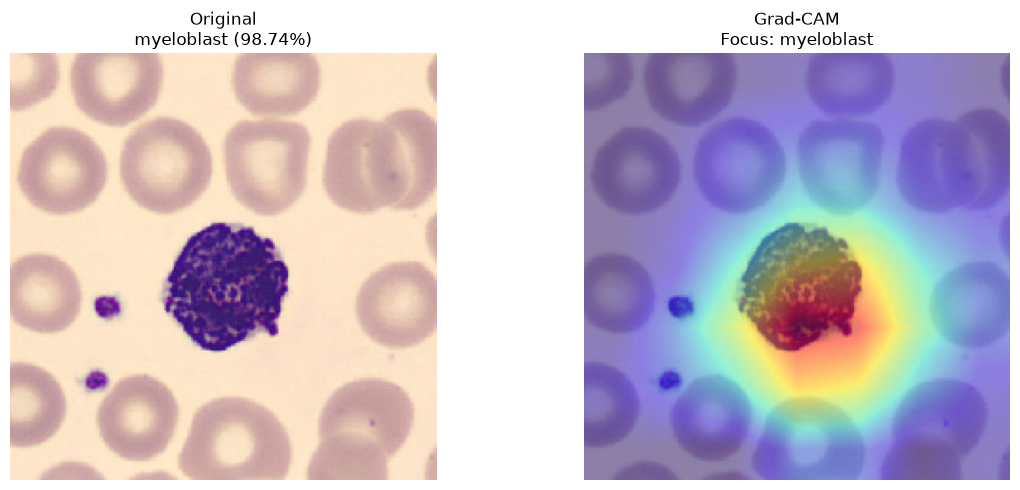


Prediction: myeloblast
Confidence: 0.9873570203781128


In [35]:
result = generate_gradcam(
    "../dataset/basophil/BA_100102.jpg",
    "basophil_gradcam.png"
)

print("\nPrediction:", result["class"])
print("Confidence:", result["confidence"])

In [38]:
test_images = {
    "basophil": "../dataset/basophil/BA_100102.jpg",
    "erythroblast": "../dataset/erythroblast/ERB_101031.jpg",
    "monocyte": "../dataset/monocyte/MO_100695.jpg",
    "myeloblast": "../dataset/myeloblast/MYO_0001.jpg",
    "seg_neutrophil": "../dataset/seg_neutrophil/NGS_0014.jpg"
}


True class: basophil
Saved: ../images/xai_results/basophil_gradcam.png


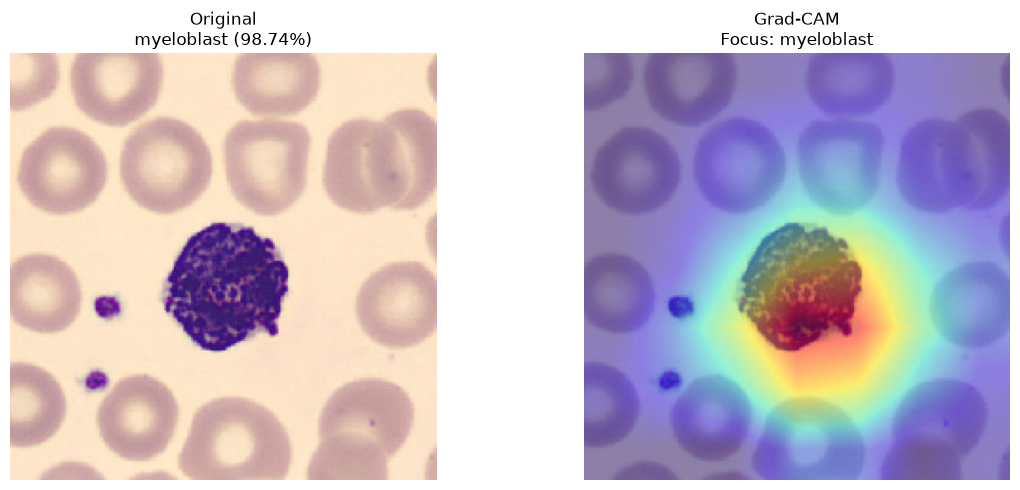


True class: erythroblast
Saved: ../images/xai_results/erythroblast_gradcam.png


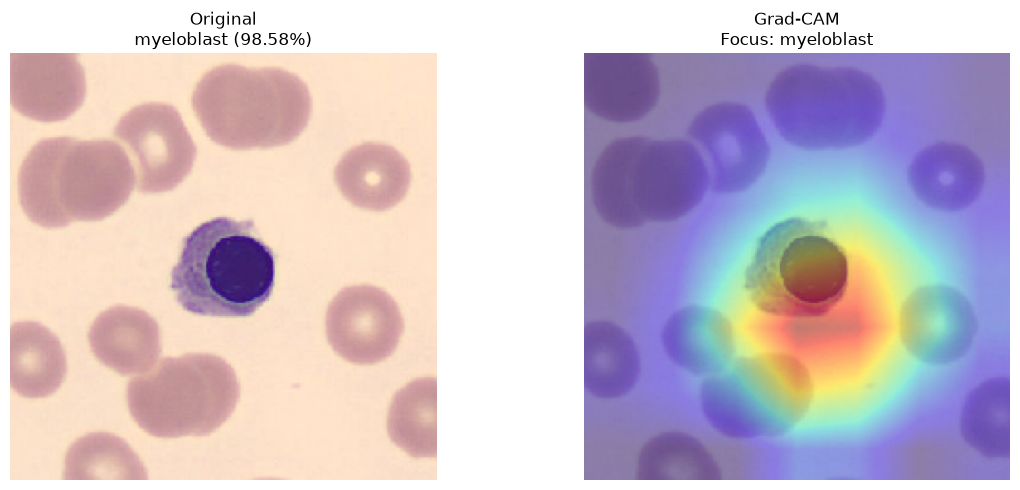


True class: monocyte
Saved: ../images/xai_results/monocyte_gradcam.png


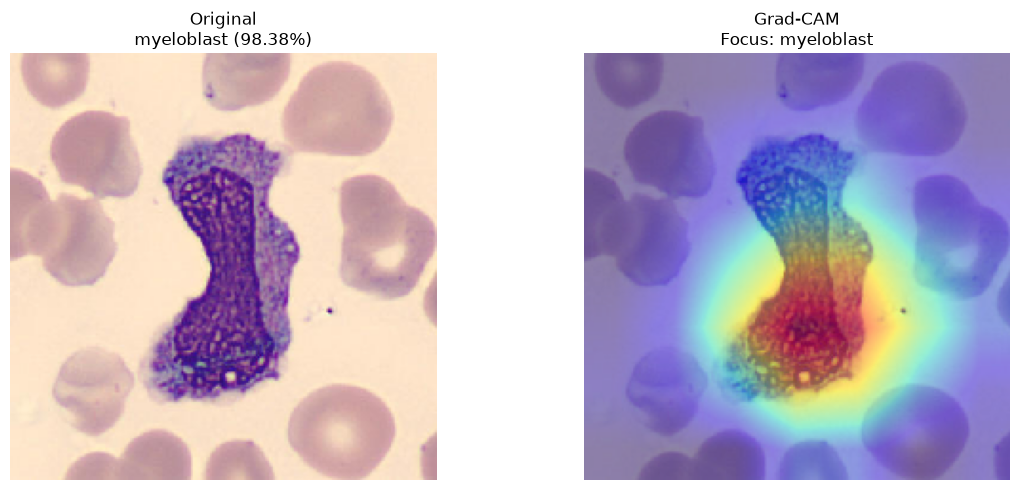


True class: myeloblast
Saved: ../images/xai_results/myeloblast_gradcam.png


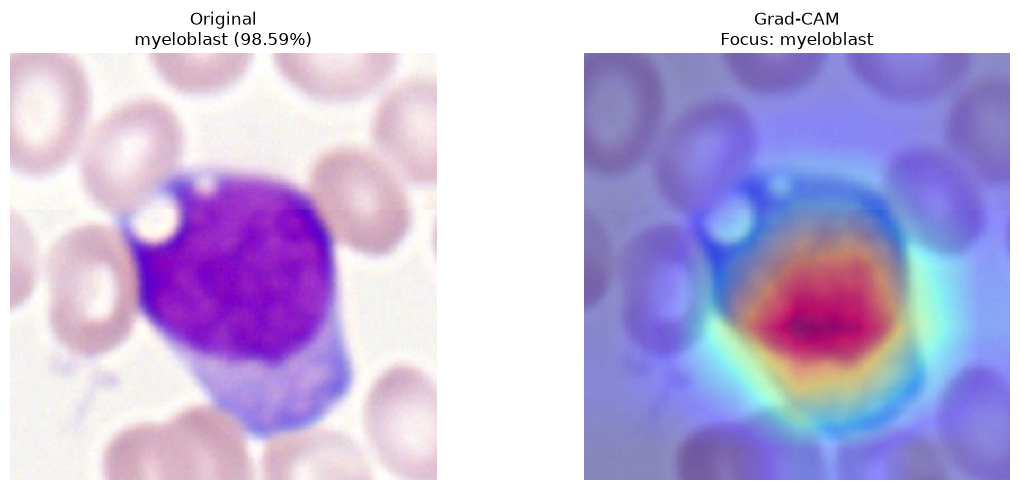


True class: seg_neutrophil
Saved: ../images/xai_results/seg_neutrophil_gradcam.png


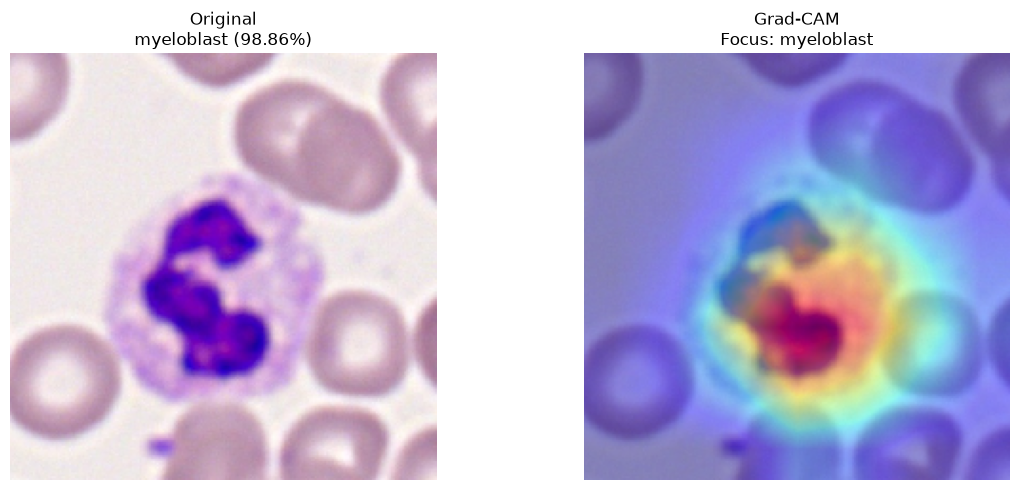

In [39]:
results = {}

for true_class, path in test_images.items():

    print("\n" + "=" * 50)
    print("True class:", true_class)
    print("=" * 50)

    results[true_class] = generate_gradcam(
        path,
        f"{true_class}_gradcam.png"
    )

In [40]:
import pandas as pd

summary = []

for true_class, result in results.items():

    summary.append({
        "True Class": true_class,
        "Predicted Class": result["class"],
        "Confidence (%)": round(
            result["confidence"] * 100,
            2
        )
    })

results_df = pd.DataFrame(summary)

results_df

,True Class,Predicted Class,Confidence (%)
0,basophil,myeloblast,98.74
1,erythroblast,myeloblast,98.58
2,monocyte,myeloblast,98.38
3,myeloblast,myeloblast,98.59
4,seg_neutrophil,myeloblast,98.86


In [41]:
import os
import glob

sample_images = []

for class_name in class_names:
    folder = os.path.join("../dataset", class_name)
    images = glob.glob(os.path.join(folder, "*.jpg"))

    if len(images) > 0:
        sample_images.append((class_name, images[0]))

print("Images selected:")
for true_class, path in sample_images:
    print(true_class, "->", path)

Images selected:
basophil -> ../dataset\basophil\BA_100102.jpg
erythroblast -> ../dataset\erythroblast\ERB_101031.jpg
monocyte -> ../dataset\monocyte\MO_100695.jpg
myeloblast -> ../dataset\myeloblast\MYO_0001.jpg
seg_neutrophil -> ../dataset\seg_neutrophil\NGS_0014.jpg


In [44]:
print("Model inputs:")
print(grad_model.inputs)

print("\nInput name:")
print(grad_model.inputs[0].name)

Model inputs:
[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_2>]

Input name:
input_layer_2


In [47]:
def generate_gradcam(image_path, save_name=None):

    # -----------------------------
    # Load image
    # -----------------------------
    img = image.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array_local = image.img_to_array(img)
    img_array_local = np.expand_dims(img_array_local, axis=0)
    img_array_local = img_array_local.astype("float32") / 255.0

    # -----------------------------
    # Prediction + gradients
    # -----------------------------
    with tf.GradientTape() as tape:

        conv_outputs_local, predictions_local = grad_model(
            {
                grad_model.inputs[0].name: img_array_local
            },
            training=False
        )

        predicted_index_local = tf.argmax(
            predictions_local[0]
        )

        class_output_local = predictions_local[
            :, predicted_index_local
        ]

    # -----------------------------
    # Gradients
    # -----------------------------
    grads_local = tape.gradient(
        class_output_local,
        conv_outputs_local
    )

    # -----------------------------
    # Grad-CAM
    # -----------------------------
    conv_outputs_local = conv_outputs_local[0]
    grads_local = grads_local[0]

    weights_local = tf.reduce_mean(
        grads_local,
        axis=(0, 1)
    )

    cam_local = tf.reduce_sum(
        conv_outputs_local * weights_local,
        axis=-1
    )

    cam_local = tf.maximum(cam_local, 0)

    cam_local = cam_local / (
        tf.reduce_max(cam_local) + 1e-8
    )

    heatmap_local = cam_local.numpy()

    # -----------------------------
    # Resize heatmap
    # -----------------------------
    heatmap_resized_local = tf.image.resize(
        heatmap_local[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()

    # -----------------------------
    # Original image
    # -----------------------------
    original_local = np.array(img)

    predicted_name = class_names[
        predicted_index_local.numpy()
    ]

    confidence_local = float(
        predictions_local[
            0,
            predicted_index_local
        ]
    )

    # -----------------------------
    # Visualization
    # -----------------------------
    fig = plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(original_local)
    plt.title(
        f"Original\n"
        f"{predicted_name} "
        f"({confidence_local * 100:.2f}%)"
    )
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(original_local)
    plt.imshow(
        heatmap_resized_local,
        cmap="jet",
        alpha=0.45
    )

    plt.title(
        f"Grad-CAM\n"
        f"Focus: {predicted_name}"
    )

    plt.axis("off")

    plt.tight_layout()

    # -----------------------------
    # Save
    # -----------------------------
    if save_name is not None:

        os.makedirs(
            "../images/xai_results",
            exist_ok=True
        )

        save_path = os.path.join(
            "../images/xai_results",
            save_name
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print("Saved:", save_path)

    plt.show()

    return {
        "class": predicted_name,
        "confidence": confidence_local,
        "heatmap": heatmap_resized_local
    }

Saved: ../images/xai_results\basophil_xai.png


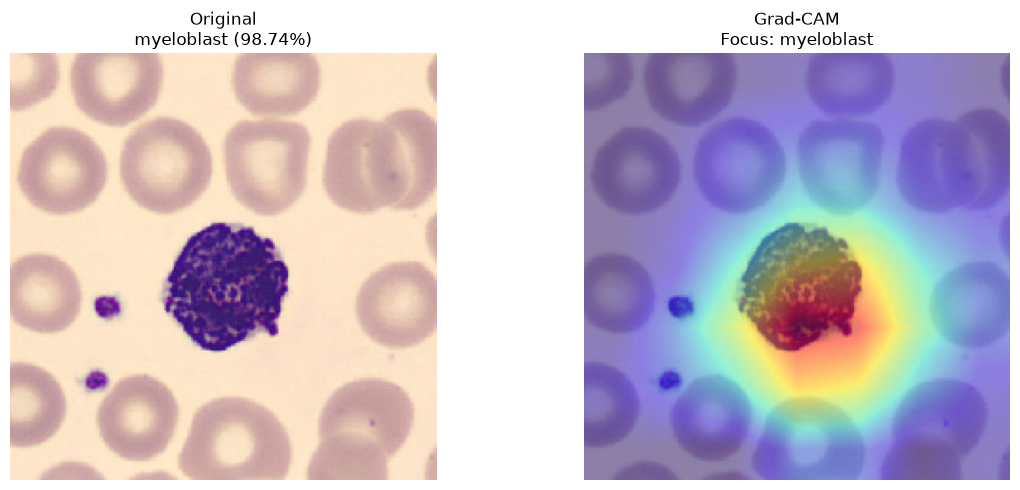


Predicted class: myeloblast
Confidence: 0.9873570203781128


In [48]:
result = generate_gradcam(
    "../dataset/basophil/BA_100102.jpg",
    "basophil_xai.png"
)

print("\nPredicted class:", result["class"])
print("Confidence:", result["confidence"])

In [49]:
test_images = {
    "basophil": "../dataset/basophil/BA_100102.jpg",
    "erythroblast": "../dataset/erythroblast/ERB_101031.jpg",
    "monocyte": "../dataset/monocyte/MO_100695.jpg",
    "myeloblast": "../dataset/myeloblast/MYO_0001.jpg",
    "seg_neutrophil": "../dataset/seg_neutrophil/NGS_0014.jpg"
}

batch_results = {}


TRUE CLASS: basophil
Saved: ../images/xai_results\basophil_gradcam.png


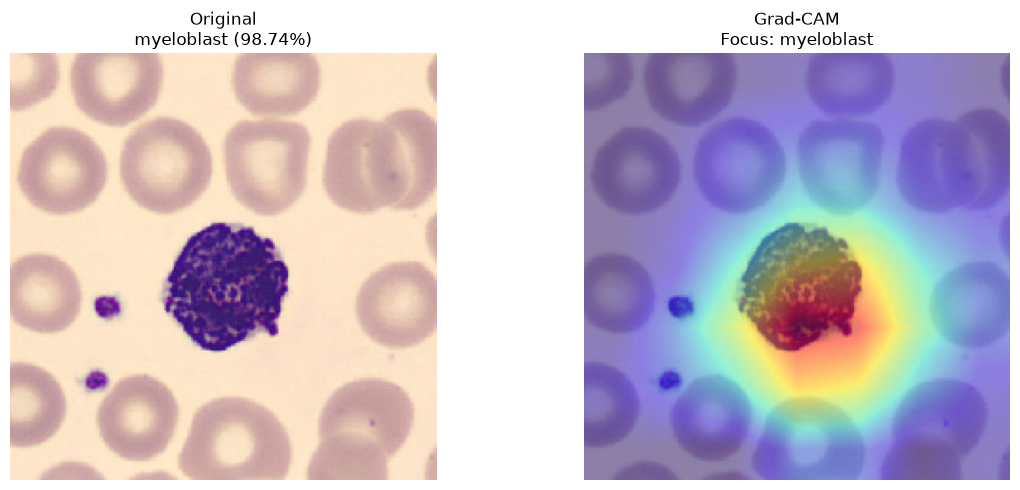


TRUE CLASS: erythroblast
Saved: ../images/xai_results\erythroblast_gradcam.png


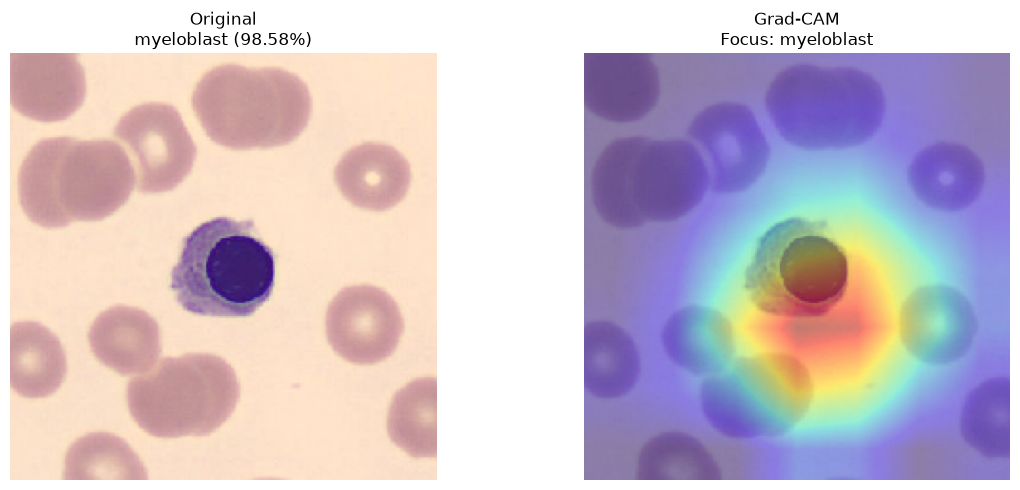


TRUE CLASS: monocyte
Saved: ../images/xai_results\monocyte_gradcam.png


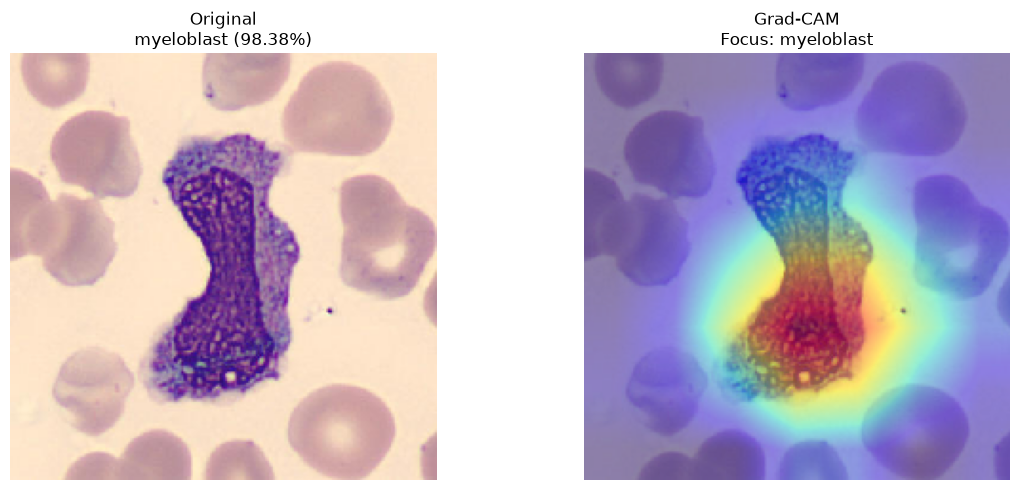


TRUE CLASS: myeloblast
Saved: ../images/xai_results\myeloblast_gradcam.png


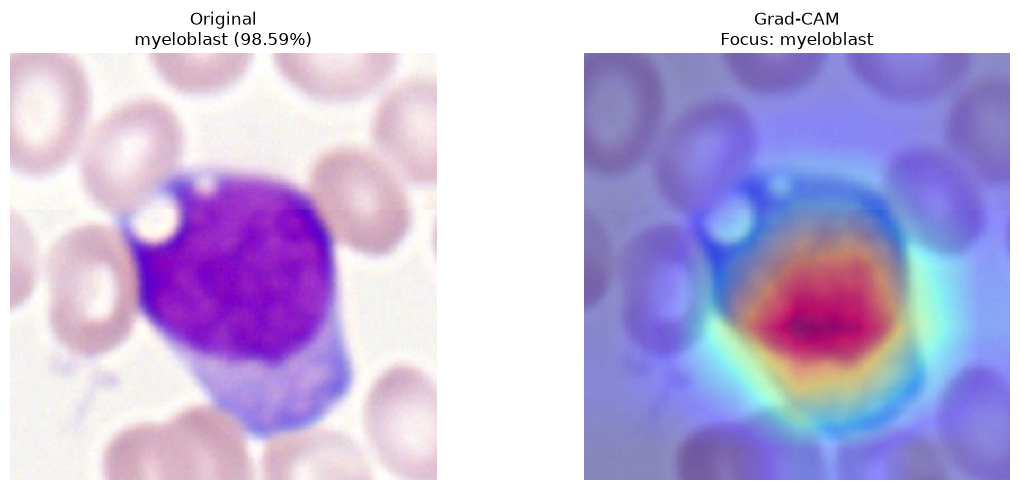


TRUE CLASS: seg_neutrophil
Saved: ../images/xai_results\seg_neutrophil_gradcam.png


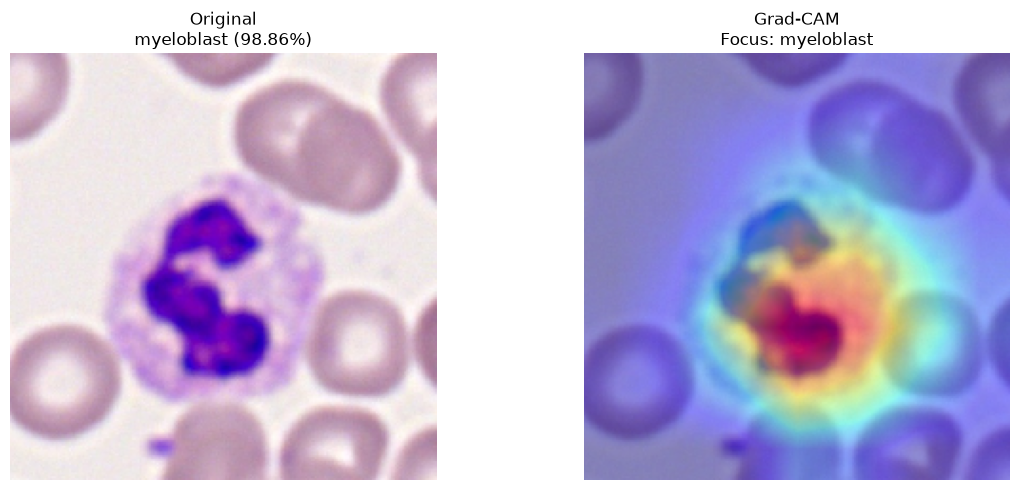

In [50]:
for true_class, image_path in test_images.items():

    print("\n" + "=" * 60)
    print("TRUE CLASS:", true_class)
    print("=" * 60)

    result = generate_gradcam(
        image_path,
        f"{true_class}_gradcam.png"
    )

    batch_results[true_class] = result

In [51]:
import pandas as pd

rows = []

for true_class, result in batch_results.items():

    rows.append({
        "True Class": true_class,
        "Predicted Class": result["class"],
        "Confidence (%)": round(
            result["confidence"] * 100,
            2
        ),
        "Correct": (
            true_class == result["class"]
        )
    })

xai_results_df = pd.DataFrame(rows)

xai_results_df

,True Class,Predicted Class,Confidence (%),Correct
0,basophil,myeloblast,98.74,False
1,erythroblast,myeloblast,98.58,False
2,monocyte,myeloblast,98.38,False
3,myeloblast,myeloblast,98.59,True
4,seg_neutrophil,myeloblast,98.86,False


In [52]:
accuracy = (
    xai_results_df["Correct"].mean() * 100
)

print(
    f"XAI sample accuracy: {accuracy:.2f}%"
)

XAI sample accuracy: 20.00%


In [53]:
import os

xai_folder = "../images/xai_results"

print("Generated XAI files:")

for filename in os.listdir(xai_folder):
    print(" -", filename)

Generated XAI files:
 - basophil_gradcam.png
 - basophil_xai.png
 - erythroblast_gradcam.png
 - erythroblast_xai.png
 - gradcam_myeloblast.png
 - monocyte_gradcam.png
 - monocyte_xai.png
 - myeloblast_gradcam.png
 - myeloblast_xai.png
 - seg_neutrophil_gradcam.png
 - seg_neutrophil_xai.png


In [58]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [57]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image

background_images = []

for class_name in class_names:

    folder = os.path.join("../dataset", class_name)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(files) > 0:

        img_path = os.path.join(folder, files[0])

        img = image.load_img(
            img_path,
            target_size=(224, 224)
        )

        img_array = image.img_to_array(img)
        img_array = img_array.astype("float32") / 255.0

        background_images.append(img_array)

background_images = np.array(background_images)

print("Background shape:", background_images.shape)

Background shape: (5, 224, 224, 3)


In [59]:
shap_image_path = "../dataset/myeloblast/MYO_0001.jpg"

img = image.load_img(
    shap_image_path,
    target_size=(224, 224)
)

shap_image = image.img_to_array(img)
shap_image = shap_image.astype("float32") / 255.0

shap_input = np.expand_dims(
    shap_image,
    axis=0
)

print("SHAP input shape:", shap_input.shape)

SHAP input shape: (1, 224, 224, 3)


In [60]:
shap_prediction = functional_model.predict(
    shap_input,
    verbose=0
)

shap_predicted_index = np.argmax(
    shap_prediction[0]
)

shap_predicted_class = class_names[
    shap_predicted_index
]

shap_confidence = float(
    shap_prediction[0, shap_predicted_index]
)

print("Predicted class :", shap_predicted_class)
print("Confidence      :", shap_confidence)

Predicted class : myeloblast
Confidence      : 0.9859214425086975


In [63]:
# Create a SHAP image masker
masker = shap.maskers.Image(
    "blur(32,32)",
    (224, 224, 3)
)

print("SHAP image masker created successfully.")

SHAP image masker created successfully.


In [64]:
explainer = shap.Explainer(
    functional_model,
    masker,
    output_names=class_names
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [65]:
shap_values = explainer(
    shap_input,
    max_evals=100,
    batch_size=1
)

print("SHAP values generated successfully.")
print("Shape:", shap_values.values.shape)

PartitionExplainer explainer: 2it [00:41, 41.42s/it]               

SHAP values generated successfully.
Shape: (1, 224, 224, 3, 5)


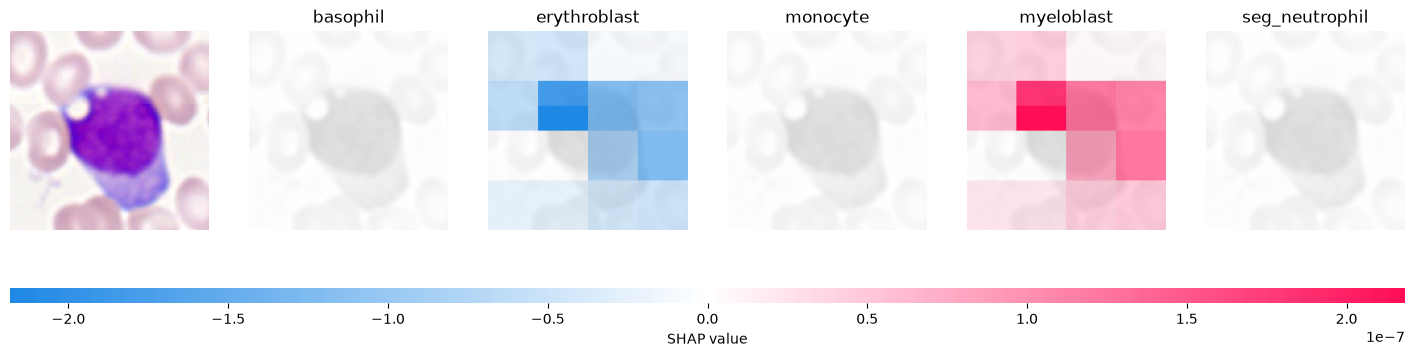

In [67]:
shap.image_plot(
    shap_values,
    show=True
)


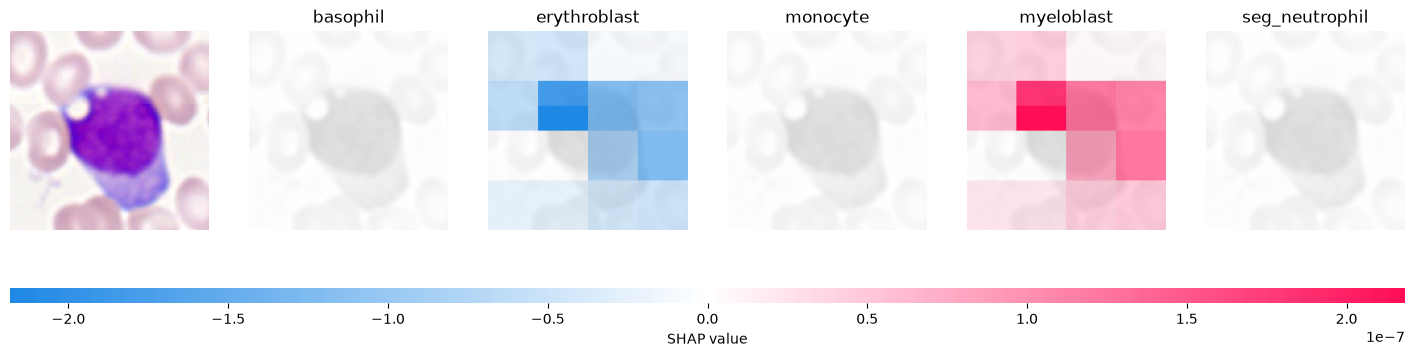

SHAP explanation saved.


In [68]:
os.makedirs("../images/xai_results", exist_ok=True)

shap.image_plot(
    shap_values,
    show=False
)

plt.savefig(
    "../images/xai_results/myeloblast_shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP explanation saved.")

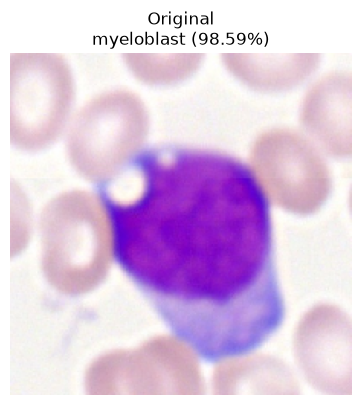

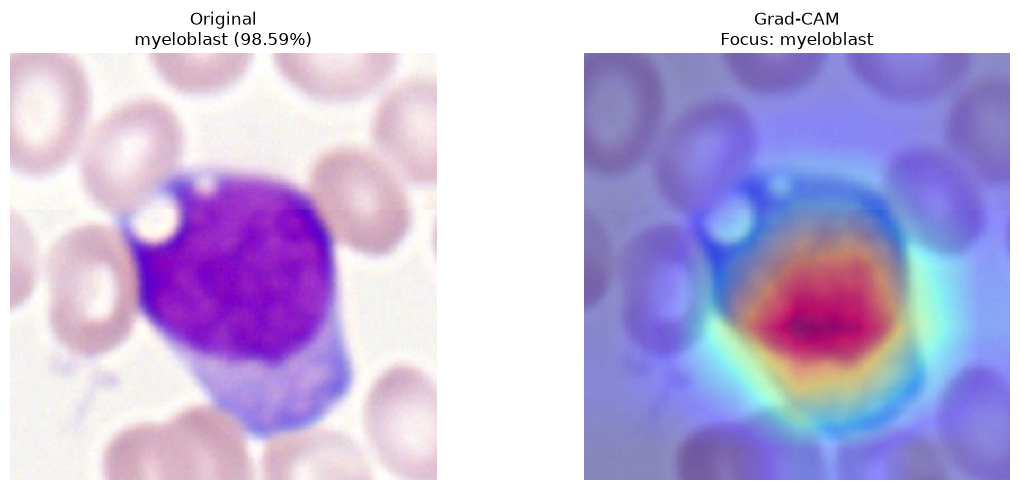

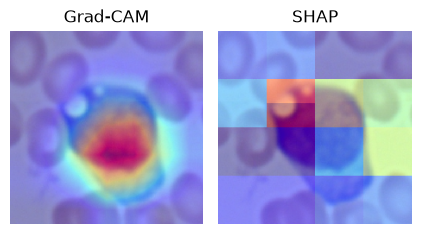

In [69]:
# Same image used for both explanations

fig = plt.figure(figsize=(15, 5))

# -----------------------------
# 1. Original image
# -----------------------------
ax1 = plt.subplot(1, 3, 1)

ax1.imshow(shap_image)
ax1.set_title(
    f"Original\n"
    f"{shap_predicted_class} "
    f"({shap_confidence * 100:.2f}%)"
)
ax1.axis("off")


# -----------------------------
# 2. Grad-CAM
# -----------------------------
gradcam_result = generate_gradcam(
    shap_image_path
)

ax2 = plt.subplot(1, 3, 2)

ax2.imshow(shap_image)
ax2.imshow(
    gradcam_result["heatmap"],
    cmap="jet",
    alpha=0.45
)

ax2.set_title("Grad-CAM")
ax2.axis("off")


# -----------------------------
# 3. SHAP
# -----------------------------
ax3 = plt.subplot(1, 3, 3)

# Get SHAP values for predicted class
shap_array = shap_values.values

if shap_array.ndim == 5:
    shap_class = shap_array[0, :, :, :, shap_predicted_index]
else:
    shap_class = shap_array[0]

# Convert RGB attribution to magnitude
shap_heatmap = np.mean(
    np.abs(shap_class),
    axis=-1
)

# Normalize
shap_heatmap = (
    shap_heatmap /
    (np.max(shap_heatmap) + 1e-8)
)

ax3.imshow(shap_image)
ax3.imshow(
    shap_heatmap,
    cmap="jet",
    alpha=0.45
)

ax3.set_title("SHAP")
ax3.axis("off")

plt.tight_layout()
plt.show()

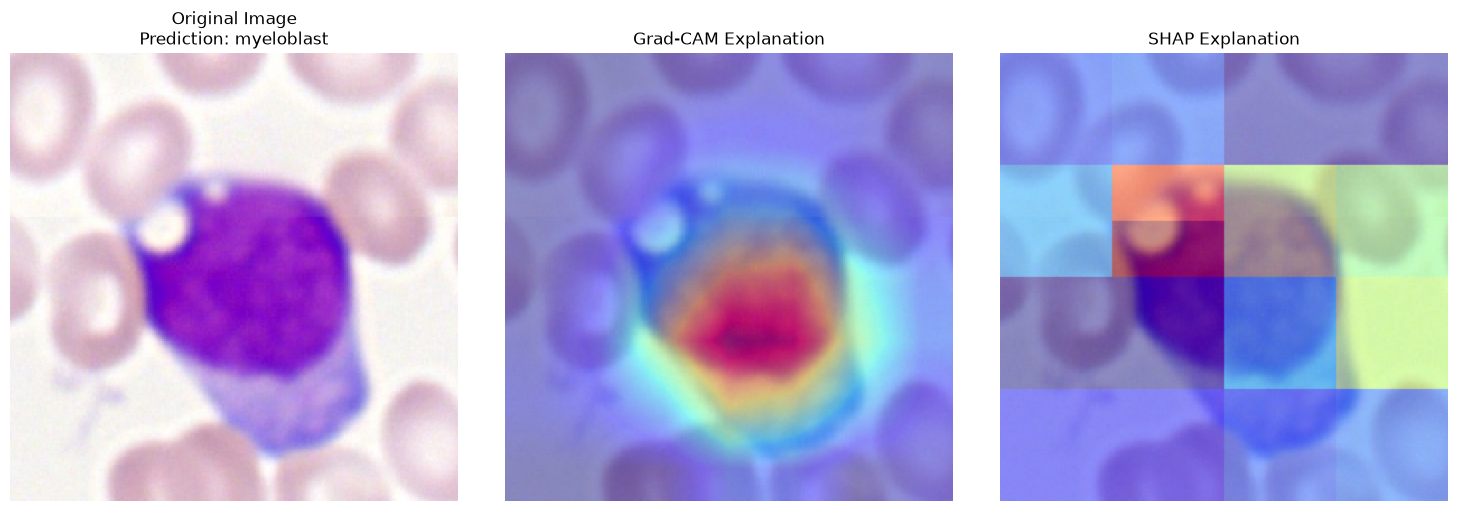

Saved: ../images/xai_results/xai_comparison_myeloblast.png


In [70]:
comparison_path = "../images/xai_results/xai_comparison_myeloblast.png"

fig = plt.figure(figsize=(15, 5))

# Original
ax1 = plt.subplot(1, 3, 1)
ax1.imshow(shap_image)
ax1.set_title(
    f"Original Image\n"
    f"Prediction: {shap_predicted_class}"
)
ax1.axis("off")

# Grad-CAM
ax2 = plt.subplot(1, 3, 2)
ax2.imshow(shap_image)
ax2.imshow(
    gradcam_result["heatmap"],
    cmap="jet",
    alpha=0.45
)
ax2.set_title("Grad-CAM Explanation")
ax2.axis("off")

# SHAP
ax3 = plt.subplot(1, 3, 3)
ax3.imshow(shap_image)
ax3.imshow(
    shap_heatmap,
    cmap="jet",
    alpha=0.45
)
ax3.set_title("SHAP Explanation")
ax3.axis("off")

plt.tight_layout()

fig.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_path)

In [71]:
comparison = pd.DataFrame({
    "Method": [
        "Grad-CAM",
        "SHAP"
    ],
    "Purpose": [
        "Highlights important spatial regions",
        "Shows feature contribution toward prediction"
    ],
    "Applied To": [
        "Final convolutional feature maps",
        "Input image features"
    ],
    "Interpretation": [
        "Where the CNN focused",
        "Which image regions contributed to prediction"
    ]
})

comparison

,Method,Purpose,Applied To,Interpretation
0,Grad-CAM,Highlights important spatial regions,Final convolutional feature maps,Where the CNN focused
1,SHAP,Shows feature contribution toward prediction,Input image features,Which image regions contributed to prediction


In [72]:
print("=" * 60)
print("SYNTHMICRO PHASE 6 — XAI OUTPUTS")
print("=" * 60)

for file in sorted(os.listdir("../images/xai_results")):
    print("✓", file)

SYNTHMICRO PHASE 6 — XAI OUTPUTS
✓ basophil_gradcam.png
✓ basophil_xai.png
✓ erythroblast_gradcam.png
✓ erythroblast_xai.png
✓ gradcam_myeloblast.png
✓ monocyte_gradcam.png
✓ monocyte_xai.png
✓ myeloblast_gradcam.png
✓ myeloblast_shap.png
✓ myeloblast_xai.png
✓ seg_neutrophil_gradcam.png
✓ seg_neutrophil_xai.png
✓ xai_comparison_myeloblast.png


In [73]:
final_xai_report = pd.DataFrame({
    "Model": ["ResNet50"],
    "Predicted Class": [shap_predicted_class],
    "Confidence (%)": [round(shap_confidence * 100, 2)],
    "XAI Methods": ["Grad-CAM + SHAP"],
    "Grad-CAM Layer": ["conv5_block3_out"]
})

final_xai_report

,Model,Predicted Class,Confidence (%),XAI Methods,Grad-CAM Layer
0,ResNet50,myeloblast,98.59,Grad-CAM + SHAP,conv5_block3_out


In [74]:
final_xai_report.to_csv(
    "../images/xai_results/xai_report.csv",
    index=False
)

print("XAI report saved successfully.")

XAI report saved successfully.


In [75]:
import os

output_dir = "../images/xai_results"

print("PHASE 6 OUTPUTS")
print("=" * 50)

for root, dirs, files in os.walk(output_dir):
    for file in files:
        print(os.path.join(root, file))

PHASE 6 OUTPUTS
../images/xai_results\basophil_gradcam.png
../images/xai_results\basophil_xai.png
../images/xai_results\erythroblast_gradcam.png
../images/xai_results\erythroblast_xai.png
../images/xai_results\gradcam_myeloblast.png
../images/xai_results\monocyte_gradcam.png
../images/xai_results\monocyte_xai.png
../images/xai_results\myeloblast_gradcam.png
../images/xai_results\myeloblast_shap.png
../images/xai_results\myeloblast_xai.png
../images/xai_results\seg_neutrophil_gradcam.png
../images/xai_results\seg_neutrophil_xai.png
../images/xai_results\xai_comparison_myeloblast.png
../images/xai_results\xai_report.csv


In [76]:
# Phase 6 — Explainable AI

## Objective

The objective of Phase 6 is to improve the interpretability of the SynthMicro blood-cell classification model by applying Explainable AI techniques.

## Model

The trained ResNet50-based classification model is used for prediction.

## XAI Techniques

Two XAI approaches are applied:

1. **Grad-CAM**
   - Uses the final convolutional feature maps.
   - Target layer: `conv5_block3_out`.
   - Highlights spatial regions that contribute to the model's prediction.

2. **SHAP**
   - Provides feature-attribution information for the input image.
   - Helps identify image regions contributing positively or negatively to the prediction.

## XAI Workflow

Input Image → ResNet50 → Prediction → Grad-CAM / SHAP → Visual Explanation

## Output

The explanations are saved in:

`../images/xai_results/`

The generated visualizations allow the model's predictions to be inspected rather than treating the classifier as a black box.

SyntaxError: unterminated string literal (detected at line 18) (3567732974.py, line 18)